In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

from sklearn import datasets
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split

In [2]:
iris = datasets.load_iris()

X = iris.data[:, :2]
y = iris.target

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=5
)

In [4]:
num_classes = len(np.unique(y_train))

print("Number of classes =", num_classes)

Number of classes = 3


In [5]:
classifier = GaussianMixture(
    n_components=num_classes,
    covariance_type="full",
    random_state=20
)

In [6]:
classifier.means_ = np.array(
    [X_train[y_train == i].mean(axis=0) for i in range(num_classes)]
)

print("Initial means:")
print(classifier.means_)

Initial means:
[[5.01666667 3.4547619 ]
 [5.97435897 2.74871795]
 [6.58717949 2.98717949]]


In [7]:
classifier.fit(X_train)

GaussianMixture(n_components=3, random_state=20)

In [8]:
def draw_ellipse(position, covariance, ax=None):
    ax = ax or plt.gca()

    if covariance.shape == (2, 2):
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)
    else:
        angle = 0
        width, height = 2 * np.sqrt(covariance)

    for nsig in range(1, 4):
        ellipse = Ellipse(
            position,
            nsig * width,
            nsig * height,
            angle=angle,
            alpha=0.2
        )
        ax.add_patch(ellipse)

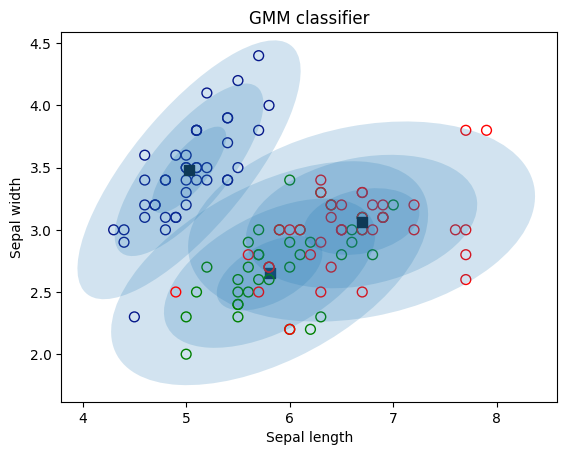

In [9]:
plt.figure()

colors = ["navy", "green", "red"]

for i, color in enumerate(colors):
    data = X_train[y_train == i]

    plt.scatter(
        data[:, 0],
        data[:, 1],
        marker="o",
        facecolors="none",
        edgecolors=color,
        s=50
    )

    plt.scatter(
        classifier.means_[i, 0],
        classifier.means_[i, 1],
        marker="s",
        color="black",
        s=60
    )

    draw_ellipse(
        classifier.means_[i],
        classifier.covariances_[i],
        plt.gca()
    )

plt.title("GMM classifier")
plt.xlabel("Sepal length")
plt.ylabel("Sepal width")

plt.show()

In [10]:
y_train_pred = classifier.predict(X_train)
accuracy_training = np.mean(y_train_pred == y_train) * 100

y_test_pred = classifier.predict(X_test)
accuracy_testing = np.mean(y_test_pred == y_test) * 100

print("Accuracy on training data =", accuracy_training)
print("Accuracy on testing data =", accuracy_testing)

Accuracy on training data = 24.166666666666668
Accuracy on testing data = 23.333333333333332
